In [9]:
# Cell 1: Setup for Question 1-2 - Class Distribution Analysis
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import numpy as np
import matplotlib.pyplot as plt
import torch
from collections import defaultdict

from data.data_loader import build_dataloaders, load_config

plt.rcParams['figure.figsize'] = (12, 6)
print("Setup done")
print(f"Project root: {project_root}")


Setup done
Project root: c:\Users\Rayanafshan\Desktop\HW3_Zanganeh_810104157\homework_code


In [10]:
# Cell 2: Load dataloaders
config_path = project_root / "config" / "config.yaml"
print(f"Loading config from: {config_path}")

loaders = build_dataloaders(str(config_path))
train_loader = loaders["train"]
val_loader = loaders["val"]
num_classes = loaders["num_classes"]

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Number of classes: {num_classes}")

Loading config from: c:\Users\Rayanafshan\Desktop\HW3_Zanganeh_810104157\homework_code\config\config.yaml
[data] Dataset1: 100 pairs
[data] Dataset2: 100 pairs
[data] Total: 200 pairs
[data] Train: 180 | Val: 20

Train batches: 45
Val batches: 5
Number of classes: 10


In [11]:
# Cell 3: Function to count class pixels
def count_class_pixels(loader, num_classes, num_batches=10):
    """
    Count pixels for each class from first num_batches
    """
    class_counts = np.zeros(num_classes, dtype=np.int64)
    total_pixels = 0
    
    for batch_idx, (images, masks) in enumerate(loader):
        if batch_idx >= num_batches:
            break
        
        for class_id in range(num_classes):
            class_counts[class_id] += (masks == class_id).sum().item()
        
        total_pixels += masks.numel()
        print(f"  Processed batch {batch_idx+1}/{num_batches}")
    
    return class_counts, total_pixels

print("Counting pixels from training set...")
class_counts, total_pixels = count_class_pixels(train_loader, num_classes, num_batches=10)
print(f"\nTotal pixels counted: {total_pixels:,}")

Counting pixels from training set...
  Processed batch 1/10
  Processed batch 2/10
  Processed batch 3/10
  Processed batch 4/10
  Processed batch 5/10
  Processed batch 6/10
  Processed batch 7/10
  Processed batch 8/10
  Processed batch 9/10
  Processed batch 10/10

Total pixels counted: 2,621,440



CLASS DISTRIBUTION IN TRAINING DATA

Class               Pixel Count   Percentage
---------------------------------------------
Background                  119      0.0045%
Field                 1,280,074     48.8309%
Player                  270,608     10.3229%
Goalkeeper               38,669      1.4751%
Referee                  11,988      0.4573%
Ball                      4,368      0.1666%
Goal Bar                 29,829      1.1379%
Advertisement           330,036     12.5899%
Audience                655,749     25.0148%
Staff                         0      0.0000%


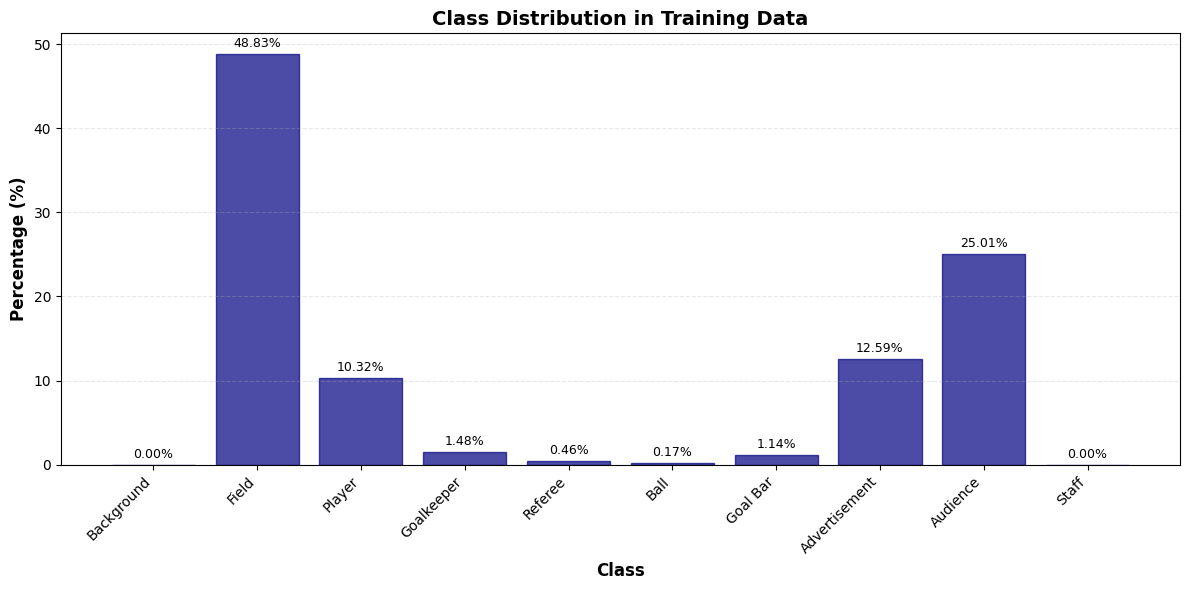

In [13]:
# Cell 4: Calculate percentages and show results with bar chart
import matplotlib.pyplot as plt
import numpy as np

class_names = [
    "Background", "Field", "Player", "Goalkeeper",
    "Referee", "Ball", "Goal Bar", "Advertisement", "Audience", "Staff"
]


percentages = (class_counts / total_pixels) * 100

print("\n" + "="*60)
print("CLASS DISTRIBUTION IN TRAINING DATA")
print("="*60)
print(f"\n{'Class':15s} {'Pixel Count':>15s} {'Percentage':>12s}")
print("-"*45)

for i, name in enumerate(class_names):
    print(f"{name:15s} {class_counts[i]:15,d} {percentages[i]:11.4f}%")

# Create bar chart
plt.figure(figsize=(12, 6))

# Create bars
bars = plt.bar(class_names, percentages, color='navy', edgecolor='navy', alpha=0.7)

# Customize the chart
plt.xlabel('Class', fontsize=12, fontweight='bold')
plt.ylabel('Percentage (%)', fontsize=12, fontweight='bold')
plt.title('Class Distribution in Training Data', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add percentage values on top of each bar
for bar, percentage in zip(bars, percentages):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{percentage:.2f}%', ha='center', va='bottom', fontsize=9)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Display the chart
plt.show()

# Optional: Save the chart as an image file
# plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')